In [39]:
import numpy as np

import torch
from torch.nn import CrossEntropyLoss, Dropout
import torch.nn.functional as F
from torch.optim import SGD, AdamW
from torch.utils.data import TensorDataset, DataLoader
from transformers import AutoTokenizer, DistilBertForSequenceClassification

import matplotlib.pyplot as plt

import os

path_processed = "data/processed/"
path_train_data = path_processed + "train_data.txt"
path_train_labels = path_processed + "train_labels.txt"
path_test_data = path_processed + "test_data.txt"
path_test_labels = path_processed + "test_labels.txt"

access_token = os.environ.get("HF_TOKEN")

N_EPOCHS = 10

# Character guesser

I fine-tune a DistilBert sequence classifier to guess what character says a line of The Philosopher's Stone script.

This notebook is a modification of the code found in this Medium article : (Fine-tuning a large language model (LLM))[https://medium.com/@anoop-singh-dev/fine-tuning-a-large-language-model-llm-3013c2bcee1e], written by Anoop Singh.

In [40]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    problem_type="multi_label_classification",
    num_labels=4,
    token=access_token,
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [41]:
model

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


Freeze all layers ...

In [42]:
for p in model.parameters():
    p.requires_grad = False

... except the last two, which are just linear :

In [60]:
for child in model.distilbert.transformer.children():
    print(child)

ModuleList(
  (0-5): 6 x TransformerBlock(
    (attention): DistilBertSelfAttention(
      (q_lin): Linear(in_features=768, out_features=768, bias=True)
      (k_lin): Linear(in_features=768, out_features=768, bias=True)
      (v_lin): Linear(in_features=768, out_features=768, bias=True)
      (out_lin): Linear(in_features=768, out_features=768, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (ffn): FFN(
      (dropout): Dropout(p=0.1, inplace=False)
      (lin1): Linear(in_features=768, out_features=3072, bias=True)
      (lin2): Linear(in_features=3072, out_features=768, bias=True)
      (activation): GELUActivation()
    )
    (output_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
  )
)


In [43]:
for child in [model.pre_classifier, model.classifier]:
    for p in child.parameters():
        p.requires_grad = True

In [44]:
def get_loader(path_data, path_labels, batch_size):

    data = np.genfromtxt(path_data, dtype=str, delimiter="\n")
    inputs = tokenizer(data.tolist(), padding=True, return_tensors="pt")

    labels = np.genfromtxt(path_labels, dtype=int)
    labels = torch.tensor(labels)
    labels = F.one_hot(labels).float()

    dataset = TensorDataset(inputs.input_ids, inputs.attention_mask, labels)
    loader = DataLoader(dataset, batch_size=batch_size)

    return loader

In [45]:
train_loader = get_loader(
    path_data=path_train_data, path_labels=path_train_labels, batch_size=4
)
test_loader = get_loader(
    path_data=path_test_data, path_labels=path_test_labels, batch_size=4
)

In [46]:
def get_accuracy(logits, labels):
    logits_argmax = torch.argmax(logits, axis=1)
    labels_argmax = torch.argmax(labels, axis=1)
    return (logits_argmax == labels_argmax).sum().item() / len(labels)

In [47]:
def test(model, test_loader):

    # Loss
    loss = CrossEntropyLoss()

    # Set model to evaluation mode
    model.eval()

    total_loss = 0
    total_acc = 0

    # Disable gradient calculation
    with torch.no_grad():
        for batch in test_loader:
            b_input_ids = batch[0]
            b_input_mask = batch[1]
            b_labels = batch[2]

            outputs = model(b_input_ids, attention_mask=b_input_mask)
            logits = outputs[0]

            b_loss = loss(logits, b_labels)
            total_loss += b_loss.item()

            b_acc = get_accuracy(logits, b_labels)
            total_acc += b_acc

    avg_loss = total_loss / len(test_loader)
    avg_acc = total_acc / len(test_loader)

    return avg_loss, avg_acc

In [ ]:
def train(model, n_epochs):

    # Loss
    loss = CrossEntropyLoss()
    # Optimizer
    # optimizer = SGD(model.parameters(), lr=0.001, momentum=0.9)
    optimizer = AdamW(model.parameters(), lr=0.001, eps=1e-8)

    avg_losses = []
    avg_accs = []
    test_avg_losses = []
    test_avg_accs = []

    # Training loop
    for epoch in range(n_epochs):

        print(f"Processing epoch {epoch} ...\r", end="")

        total_loss = 0
        total_acc = 0

        # Set model to training mode
        model.train()

        for step, batch in enumerate(train_loader):
            b_input_ids = batch[0]
            b_input_mask = batch[1]
            b_labels = batch[2]

            # Zero out gradients
            model.zero_grad()

            outputs = model(b_input_ids, attention_mask=b_input_mask)
            logits = outputs[0]

            b_loss = loss(logits, b_labels)
            total_loss += b_loss.item()

            b_acc = get_accuracy(logits, b_labels)
            total_acc += b_acc

            # Backpropagation
            b_loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            # Update model parameters
            optimizer.step()

        avg_loss = total_loss / len(train_loader)
        avg_acc = total_acc / len(train_loader)
        avg_losses.append(avg_loss)
        avg_accs.append(avg_acc)

        # Evaluate model after each epoch
        test_avg_loss, test_avg_acc = test(model, test_loader)
        test_avg_losses.append(test_avg_loss)
        test_avg_accs.append(test_avg_acc)

    results = {
        "avg_losses": avg_losses,
        "avg_accs": avg_accs,
        "test_avg_losses": test_avg_losses,
        "test_avg_accs": test_avg_accs,
    }

    return results

In [49]:
res = train(model=model, n_epochs=N_EPOCHS)

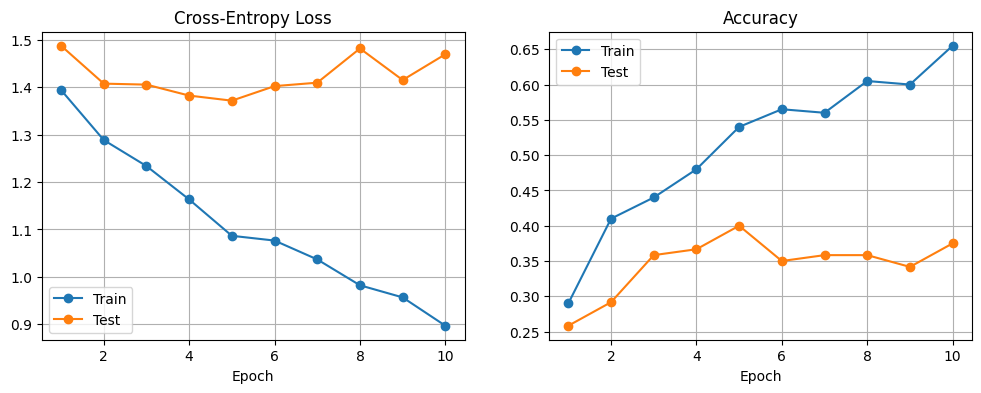

In [50]:
epochs = np.arange(1, N_EPOCHS + 1)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].set_title("Cross-Entropy Loss")
axs[0].set_xlabel("Epoch")
axs[0].plot(epochs, res["avg_losses"], marker="o", label="Train")
axs[0].plot(epochs, res["test_avg_losses"], marker="o", label="Test")
axs[0].grid()
axs[0].legend()

axs[1].set_title("Accuracy")
axs[1].set_xlabel("Epoch")
axs[1].plot(epochs, res["avg_accs"], marker="o", label="Train")
axs[1].plot(epochs, res["test_avg_accs"], marker="o", label="Test")
axs[1].grid()
axs[1].legend()

plt.show()

# WIP

I am currently working on reducing this model's overfitting. Due to the fact that I am using this "toy" dataset, which is quite small, the model tends to overfit. For this reason, I am experimenting with the following methods to avoid this issue :
- Increasing dropout. Some hidden layers of the model, in the Transformer Blocks, can have a higher dropout. This will avoid the model fitting the noise and errors of the training data.
- Freezing the first layers. The first layers of the model are embeddings and robust connections that can be leveraged for this application. Only the last blocks and layers need to be fine-tuned for this character guesser.
- Reducing the number of epochs. Once I have an experiment with a large number of epochs, the optimal number of epochs can be found to be the minimum validation loss. However, in this "toy" example, I have not done a train-validation split.